In [39]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [40]:
# ============================================================
# 2️⃣ LOAD & PREPROCESS MULTI-YEAR NSE DATASET
# ============================================================

df = pd.read_csv("NIFTY_4_Years.csv", encoding="utf-8-sig")

# Clean columns
df.columns = df.columns.str.strip()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort ascending
df = df.sort_values("Date")

# Set index
df.set_index("Date", inplace=True)

# Use Close price
data = df[['Close']]

# Train-Test Split (80-20)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print("Training size:", len(train))
print("Testing size :", len(test))

Training size: 795
Testing size : 199


In [41]:
# ============================================================
# 3️⃣ SCALING FOR DEEP LEARNING
# ============================================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [42]:
# ============================================================
# 4️⃣ HELPER FUNCTIONS
# ============================================================

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)


def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2


time_steps = 60

In [43]:
# ==============================
# ARIMA + LSTM (Safe + Corrected)
# ==============================

time_steps = 20

# --- ARIMA ---
arima_model = ARIMA(train['Close'], order=(3,1,1))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

# --- Residuals ---
residuals = test['Close'].values - arima_forecast.values
residuals = residuals.reshape(-1,1)

# Check if enough data
if len(residuals) <= time_steps:
    print("Not enough test data for LSTM residual modeling.")
    
    # Avoid NameError later
    rmse1, mae1, r21 = None, None, None

else:
    # --- Scale residuals ---
    res_scaler = MinMaxScaler()
    res_scaled = res_scaler.fit_transform(residuals)

    # --- Create sequences ---
    X_res, y_res = create_sequences(res_scaled, time_steps)

    print("Residual sequence shape:", X_res.shape)

    # --- LSTM Model ---
    model1 = Sequential()
    model1.add(LSTM(64, activation='relu', input_shape=(time_steps,1)))
    model1.add(Dense(1))

    model1.compile(optimizer='adam', loss='mse')

    model1.fit(X_res, y_res, epochs=30, batch_size=32, verbose=0)

    # --- Predict residuals ---
    lstm_res_pred = model1.predict(X_res)
    lstm_res_pred = res_scaler.inverse_transform(lstm_res_pred)

    # --- Final hybrid prediction ---
    final_arima_lstm = arima_forecast[time_steps:].values + lstm_res_pred.flatten()

    actual1 = test['Close'].values[time_steps:]

    # --- Store metrics correctly ---
    rmse1, mae1, r21 = evaluate_model(actual1, final_arima_lstm, "ARIMA + LSTM")

Residual sequence shape: (179, 20, 1)
6/6 [==============================] - 0s 3ms/step

ARIMA + LSTM
RMSE: 301.15280728526267
MAE : 245.39643916408528
R2  : 0.8469413069097707


In [44]:
# ============================================================
# SARIMA + LSTM
# ============================================================

sarima_model = SARIMAX(train['Close'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit()

sarima_forecast = sarima_result.forecast(steps=len(test))

residuals_s = test['Close'].values - sarima_forecast.values
residuals_s = residuals_s.reshape(-1,1)

res_scaler_s = MinMaxScaler()
res_scaled_s = res_scaler_s.fit_transform(residuals_s)

X_res_s, y_res_s = create_sequences(res_scaled_s, time_steps)

model2 = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps,1)),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
model2.fit(X_res_s, y_res_s, epochs=30, batch_size=32, verbose=0)

lstm_res_pred_s = model2.predict(X_res_s)
lstm_res_pred_s = res_scaler_s.inverse_transform(lstm_res_pred_s)

final_sarima_lstm = sarima_forecast[time_steps:].values + lstm_res_pred_s.flatten()
actual2 = test['Close'].values[time_steps:]

rmse2, mae2, r22 = evaluate_model(actual2, final_sarima_lstm, "SARIMA + LSTM")

6/6 [==============================] - 0s 3ms/step

SARIMA + LSTM
RMSE: 343.2000217778781
MAE : 286.17967973102486
R2  : 0.8012172097575512


In [45]:
# ============================================================
# RNN + LSTM
# ============================================================

X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

model3 = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(time_steps,1)),
    LSTM(64),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
model3.fit(X_train, y_train, epochs=40, batch_size=32, verbose=0)

rnn_lstm_pred = model3.predict(X_test)
rnn_lstm_pred = scaler.inverse_transform(rnn_lstm_pred)
actual3 = scaler.inverse_transform(y_test)

rmse3, mae3, r23 = evaluate_model(actual3, rnn_lstm_pred, "RNN + LSTM")

6/6 [==============================] - 0s 4ms/step

RNN + LSTM
RMSE: 238.1641479204403
MAE : 185.40584628142466
R2  : 0.904272450910259


In [46]:
# ============================================================
# SARIMA + RNN
# ============================================================

residuals2 = test['Close'].values - sarima_forecast.values
residuals2 = residuals2.reshape(-1,1)

res_scaler2 = MinMaxScaler()
res_scaled2 = res_scaler2.fit_transform(residuals2)

X_res2, y_res2 = create_sequences(res_scaled2, time_steps)

model4 = Sequential([
    SimpleRNN(64, input_shape=(time_steps,1)),
    Dense(1)
])

model4.compile(optimizer='adam', loss='mse')
model4.fit(X_res2, y_res2, epochs=30, batch_size=32, verbose=0)

rnn_res_pred = model4.predict(X_res2)
rnn_res_pred = res_scaler2.inverse_transform(rnn_res_pred)

final_sarima_rnn = sarima_forecast[time_steps:].values + rnn_res_pred.flatten()
actual4 = test['Close'].values[time_steps:]

rmse4, mae4, r24 = evaluate_model(actual4, final_sarima_rnn, "SARIMA + RNN")

6/6 [==============================] - 0s 2ms/step

SARIMA + RNN
RMSE: 313.2533009820096
MAE : 247.1420231351962
R2  : 0.8343942235504617


In [47]:
results = pd.DataFrame({
    "Model": ["ARIMA+LSTM", "SARIMA+LSTM", "RNN+LSTM", "SARIMA+RNN"],
    "RMSE": [rmse1, rmse2, rmse3, rmse4],
    "MAE": [mae1, mae2, mae3, mae4],
    "R2": [r21, r22, r23, r24]
})

print("\nFinal Model Comparison:")
print(results)


Final Model Comparison:
         Model        RMSE         MAE        R2
0   ARIMA+LSTM  301.152807  245.396439  0.846941
1  SARIMA+LSTM  343.200022  286.179680  0.801217
2     RNN+LSTM  238.164148  185.405846  0.904272
3   SARIMA+RNN  313.253301  247.142023  0.834394


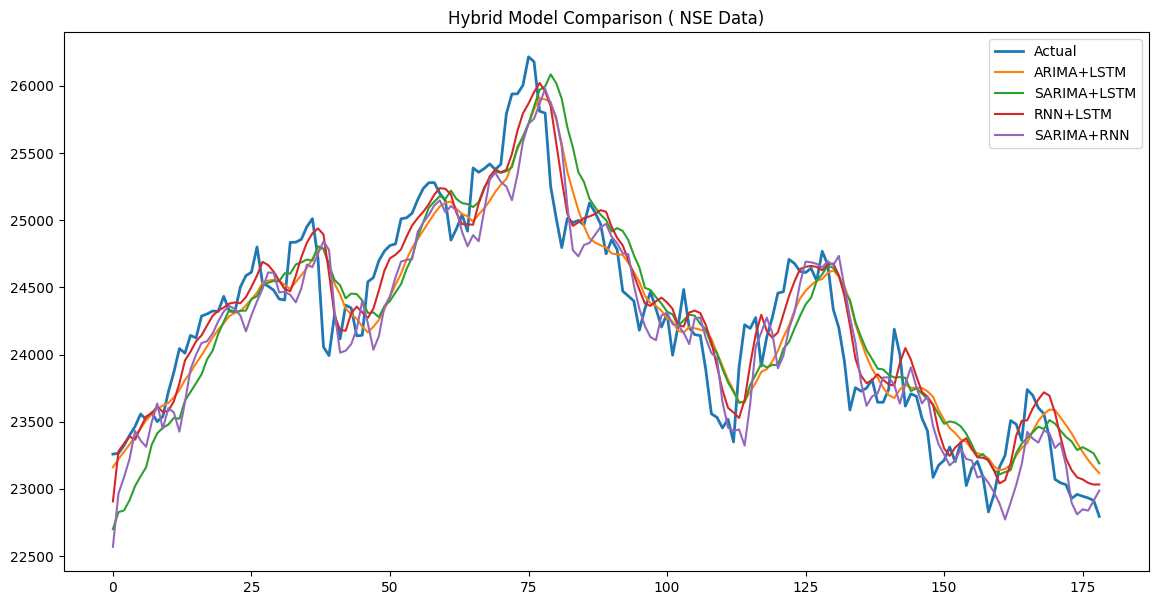

In [48]:
plt.figure(figsize=(14,7))

plt.plot(actual1, label="Actual", linewidth=2)
plt.plot(final_arima_lstm, label="ARIMA+LSTM")
plt.plot(final_sarima_lstm, label="SARIMA+LSTM")
plt.plot(rnn_lstm_pred, label="RNN+LSTM")
plt.plot(final_sarima_rnn, label="SARIMA+RNN")

plt.legend()
plt.title("Hybrid Model Comparison ( NSE Data)")
plt.show()